Generation 1: Best Affinity = 0.1000
Generation 2: Best Affinity = 0.1000
Generation 3: Best Affinity = 0.1000
Generation 4: Best Affinity = 0.1003
Generation 5: Best Affinity = 0.1004
Generation 6: Best Affinity = 0.1004
Generation 7: Best Affinity = 0.1004
Generation 8: Best Affinity = 0.1004
Generation 9: Best Affinity = 0.1004
Generation 10: Best Affinity = 0.1004
Generation 11: Best Affinity = 0.1004
Generation 12: Best Affinity = 0.1004
Generation 13: Best Affinity = 0.1004
Generation 14: Best Affinity = 0.1004
Generation 15: Best Affinity = 0.1004
Generation 16: Best Affinity = 0.1004
Generation 17: Best Affinity = 0.1004
Generation 18: Best Affinity = 0.1004
Generation 19: Best Affinity = 0.1004
Generation 20: Best Affinity = 0.1004
Generation 21: Best Affinity = 0.1004
Generation 22: Best Affinity = 0.1004
Generation 23: Best Affinity = 0.1004
Generation 24: Best Affinity = 0.1004
Generation 25: Best Affinity = 0.1004
Generation 26: Best Affinity = 0.1004
Generation 27: Best A

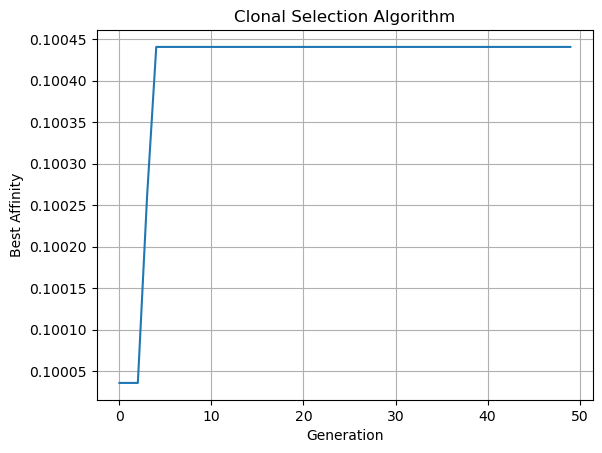

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- Step 1: Objective Function (Rastrigin) ---
def rastrigin(x):
    A = 10
    return A * len(x) + sum((xi**2 - A * np.cos(2 * np.pi * xi)) for xi in x)

# --- Parameters ---
population_size = 20
num_generations = 50
clone_factor = 5
mutation_rate = 0.1
dimension = 2
bound = (-5.12, 5.12)

# --- Step 2: Initialize population ---
def generate_population(size, dim, bound):
    return [np.random.uniform(bound[0], bound[1], dim) for _ in range(size)]

# --- Step 3: Affinity ---
def evaluate_affinity(pop):
    return [1 / (1 + rastrigin(ind)) for ind in pop]

# --- Step 4: Selection ---
def select_top(pop, affinity, num):
    indices = np.argsort(affinity)[-num:]
    return [pop[i] for i in indices]

# --- Step 5: Clone & Mutate ---
def clone_and_mutate(selected, clone_factor, mutation_rate, bound):
    clones = []
    for ind in selected:
        for _ in range(clone_factor):
            clone = ind + mutation_rate * np.random.uniform(-1, 1, len(ind))
            clone = np.clip(clone, bound[0], bound[1])
            clones.append(clone)
    return clones

# --- Step 6: Survivor Selection ---
def select_survivors(pop, clones, num):
    combined = pop + clones
    affinities = evaluate_affinity(combined)
    indices = np.argsort(affinities)[-num:]
    best = max(affinities)   # FIXED LINE
    return [combined[i] for i in indices], best

# --- MAIN ---
def main():
    population = generate_population(population_size, dimension, bound)
    best_affinities = []

    for generation in range(num_generations):
        affinity = evaluate_affinity(population)

        selected = select_top(population, affinity, population_size // 2)
        clones = clone_and_mutate(selected, clone_factor, mutation_rate, bound)

        population, best = select_survivors(population, clones, population_size)

        best_affinities.append(best)
        print(f"Generation {generation + 1}: Best Affinity = {best:.4f}")

    # --- Plot ---
    plt.plot(best_affinities)
    plt.title("Clonal Selection Algorithm")
    plt.xlabel("Generation")
    plt.ylabel("Best Affinity")
    plt.grid()
    plt.show()

# IMPORTANT FIX
if __name__ == "__main__":
    main()